# Task 1: Portfolio Data Preprocessing and Exploratory Analysis

**Project:** Portfolio Management Optimization for GMF Investments  
**Analyst:** Senior Quantitative Financial Analyst  
**Date:** 2026-01-28  

---

## Executive Summary

This notebook performs preprocessing and exploratory data analysis for a portfolio optimization project involving three assets:

- **TSLA (Tesla)** – High risk, high return equity
- **BND (Vanguard Total Bond Market ETF)** – Low risk fixed income
- **SPY (S&P 500 ETF)** – Moderate risk broad market equity

**Objectives:**
1. Extract and clean historical price data (2015-2026)
2. Engineer features for risk analysis
3. Conduct exploratory data analysis
4. Assess stationarity for time series modeling
5. Calculate key risk metrics

---

## 📦 Setup and Imports

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data extraction
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from statsmodels.tsa.stattools import adfuller

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Configure plotting aesthetics
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


---

## 📊 STEP 1: Data Extraction

We fetch historical price data for our three assets using the `yfinance` library. The data includes:
- **Open, High, Low, Close** prices
- **Adjusted Close** (accounts for splits and dividends)
- **Volume** (trading activity)

**Period:** January 1, 2015 to January 15, 2026

In [2]:
# Define portfolio assets
ASSETS = ['TSLA', 'BND', 'SPY']

# Date range
START_DATE = '2015-01-01'
END_DATE = '2026-01-15'

# Download data
print(f"Downloading data for {ASSETS} from {START_DATE} to {END_DATE}...\n")
data = yf.download(ASSETS, start=START_DATE, end=END_DATE, progress=False)

print(f"✅ Data extraction complete")
print(f"   Shape: {data.shape}")
print(f"   Date range: {data.index.min()} to {data.index.max()}")

✅ Data extraction complete
   Shape: (2775, 15)
   Date range: 2015-01-02 00:00:00 to 2026-01-14 00:00:00


In [3]:
# Display data structure
print("Data Structure:")
print(data.columns.tolist()[:6])  # Show first few columns
print("\nFirst 5 rows:")
data.head()

Data Structure:
[('Close', 'BND'), ('Close', 'SPY'), ('Close', 'TSLA'), ('High', 'BND'), ('High', 'SPY'), ('High', 'TSLA')]

First 5 rows:


Price         Close                        High                         Low  \
Ticker          BND       SPY     TSLA      BND       SPY     TSLA      BND   
Date                                                                          
2015-01-02  60.3860  170.5897  14.6207  60.4152  171.7938  14.8833  60.2179   
2015-01-05  60.5613  167.5089  14.0060  60.5832  169.7094  14.4333  60.4225   
2015-01-06  60.7367  165.9310  14.0853  60.9193  168.3392  14.2800  60.6636   
2015-01-07  60.7732  167.9988  14.0633  60.8463  168.3392  14.3187  60.6782   
2015-01-08  60.6782  170.9798  14.0413  60.7221  171.1958  14.2533  60.6198   

Price                             Open                      Volume             \
Ticker           SPY     TSLA      BND       SPY     TSLA      BND        SPY   
Date                                                                            
2015-01-02  169.5517  14.2173  60.2252  171.3786  14.8580  2218800  121465900   
2015-01-05  167.2016  13.8107  60.4517  169.5433  14.3033  5820100  169632600   
2015-01-06  165.1339  13.6140  60.6636  167.8161  14.0040  3887600  209151400   
2015-01-07  166.8113  13.9853  60.7440  167.2597  14.2233  2433400  125346700   
2015-01-08  169.3938  14.0007  60.7221  169.4104  14.1873  1873400  147217800   

Price                 
Ticker          TSLA  
Date                  
2015-01-02  71466000  
2015-01-05  80527500  
2015-01-06  93928500  
2015-01-07  44526000  
2015-01-08  51637500

**Observation:** The data is structured as a multi-index DataFrame with columns for each metric (Open, High, Low, Close, Adj Close, Volume) and sub-columns for each asset.

---

## 🧹 STEP 2: Data Cleaning and Validation

Quality checks are essential before analysis. We examine:
- Data types and structure
- Missing values
- Duplicate dates
- Trading calendar alignment

In [4]:
# Check data types
print("Data Types:")
print(data.dtypes.value_counts())
print(f"\nIndex type: {type(data.index)}")
print(f"Index dtype: {data.index.dtype}")

Data Types:
float64    12
int64       3
Name: count, dtype: int64

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index dtype: datetime64[ns]


In [5]:
# Check for missing values
missing_summary = pd.DataFrame({
    'Missing_Count': data.isnull().sum(),
    'Missing_Percentage': (data.isnull().sum() / len(data) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)

print("Missing Value Summary (Top 10):")
print(missing_summary.head(10))

total_missing = data.isnull().sum().sum()
print(f"\nTotal missing values: {total_missing}")

Missing Value Summary (Top 10):
              Missing_Count  Missing_Percentage
Price Ticker                                   
Close BND                 0                 0.0
      SPY                 0                 0.0
      TSLA                0                 0.0
High  BND                 0                 0.0
      SPY                 0                 0.0
      TSLA                0                 0.0
Low   BND                 0                 0.0
      SPY                 0                 0.0
      TSLA                0                 0.0
Open  BND                 0                 0.0

Total missing values: 0


In [6]:
# Check for duplicate dates
duplicate_dates = data.index.duplicated().sum()
print(f"Duplicate dates: {duplicate_dates}")

if duplicate_dates > 0:
    print("\nDuplicate date entries:")
    print(data[data.index.duplicated(keep=False)])

Duplicate dates: 0


In [7]:
# Handle missing values using forward fill
# Justification: Forward fill is appropriate for financial time series as it assumes
# the last known price persists until new information arrives (common in non-trading days)

data_clean = data.ffill()

# Check if any missing values remain
remaining_missing = data_clean.isnull().sum().sum()
print(f"Missing values after forward fill: {remaining_missing}")

# If any missing values at the beginning (no previous value to forward fill), use backfill
if remaining_missing > 0:
    data_clean = data_clean.bfill()
    print(f"Applied backfill for leading NaNs")
    print(f"Final missing values: {data_clean.isnull().sum().sum()}")

print("\n✅ Data cleaning complete")

Missing values after forward fill: 0

✅ Data cleaning complete


### Data Quality Summary

**Findings:**
- All data types are appropriate (float64 for prices/volume, datetime for index)
- Missing values handled using forward fill method, which is standard practice in financial data
- No duplicate dates detected
- All three assets share the same trading calendar (aligned dates)

**Implication:** The data is now ready for feature engineering and analysis.

---

## ⚙️ STEP 3: Feature Engineering

We create two critical features for risk analysis:

1. **Daily Returns:** Percentage change in adjusted close price
   - Formula: `(Price_t - Price_{t-1}) / Price_{t-1}`
   - Measures day-over-day performance

2. **Rolling Volatility:** 20-day rolling standard deviation of returns
   - Captures time-varying risk
   - 20 days ≈ 1 trading month

In [8]:
# Extract Adjusted Close prices for easier manipulation
# Handle MultiIndex (yfinance can return different column structures)
if isinstance(data_clean.columns, pd.MultiIndex):
    if 'Adj Close' in data_clean.columns.get_level_values(0):
        adj_close = data_clean.xs('Adj Close', axis=1, level=0)[ASSETS].copy()
    else:
        adj_close = data_clean.xs('Close', axis=1, level=0)[ASSETS].copy()
else:
    adj_close = data_clean['Adj Close'].copy() if 'Adj Close' in data_clean.columns else data_clean[['TSLA','BND','SPY']].copy()

print("Adjusted Close Prices:")
print(adj_close.head())
print(f"\nShape: {adj_close.shape}")

Adjusted Close Prices:
Ticker         TSLA      BND       SPY
Date                                  
2015-01-02  14.6207  60.3860  170.5897
2015-01-05  14.0060  60.5613  167.5089
2015-01-06  14.0853  60.7367  165.9310
2015-01-07  14.0633  60.7732  167.9988
2015-01-08  14.0413  60.6782  170.9798

Shape: (2775, 3)


In [9]:
# Calculate daily returns
returns = adj_close.pct_change()

# Remove first row (NaN from pct_change)
returns = returns.dropna()

print("Daily Returns:")
print(returns.head())
print(f"\nShape: {returns.shape}")
print(f"Date range: {returns.index.min()} to {returns.index.max()}")

Daily Returns:
Ticker        TSLA     BND     SPY
Date                              
2015-01-05 -0.0420  0.0029 -0.0181
2015-01-06  0.0057  0.0029 -0.0094
2015-01-07 -0.0016  0.0006  0.0125
2015-01-08 -0.0016 -0.0016  0.0177
2015-01-09 -0.0188  0.0017 -0.0080

Shape: (2774, 3)
Date range: 2015-01-05 00:00:00 to 2026-01-14 00:00:00


In [10]:
# Calculate 20-day rolling volatility
rolling_volatility = returns.rolling(window=20).std()

# Annualize volatility (multiply by sqrt(252) trading days)
rolling_volatility_annual = rolling_volatility * np.sqrt(252)

print("20-Day Rolling Volatility (Annualized):")
print(rolling_volatility_annual.tail())
print(f"\nShape: {rolling_volatility_annual.shape}")

20-Day Rolling Volatility (Annualized):
Ticker        TSLA     BND     SPY
Date                              
2026-01-08  0.4001  0.0265  0.0937
2026-01-09  0.4044  0.0255  0.0937
2026-01-12  0.4039  0.0258  0.0935
2026-01-13  0.3918  0.0228  0.0841
2026-01-14  0.3709  0.0234  0.0863

Shape: (2774, 3)


In [11]:
# Summary statistics for returns
print("Daily Returns Summary Statistics:")
returns_summary = returns.describe()
returns_summary.loc['skewness'] = returns.skew()
returns_summary.loc['kurtosis'] = returns.kurtosis()
returns_summary

Daily Returns Summary Statistics:


Ticker,TSLA,BND,SPY
count,2774.0000,2.7740e+03,2774.0000
mean,0.0019,8.1086e-05,0.0006
std,0.0363,3.3744e-03,0.0112
min,-0.2106,-5.4385e-02,-0.1094
25%,-0.0165,-1.5166e-03,-0.0037
50%,0.0012,1.2719e-04,0.0006
75%,0.0196,1.7729e-03,0.0059
max,0.2269,4.2201e-02,0.1050
skewness,0.2902,-9.2749e-01,-0.3128
kurtosis,4.4563,3.6754e+01,14.2049


### Feature Engineering Insights

**Key Observations:**
- **TSLA** shows significantly higher standard deviation in returns (higher volatility)
- **BND** exhibits the lowest volatility, consistent with its bond nature
- **SPY** sits between TSLA and BND in risk profile
- Kurtosis values indicate presence of fat tails (extreme events)

**Portfolio Implication:** The contrasting volatility profiles support diversification benefits.

---

## 📈 STEP 4: Exploratory Data Analysis (EDA)

Visual analysis reveals patterns, trends, and anomalies in the data.

### Visualization 1: Adjusted Close Price Over Time

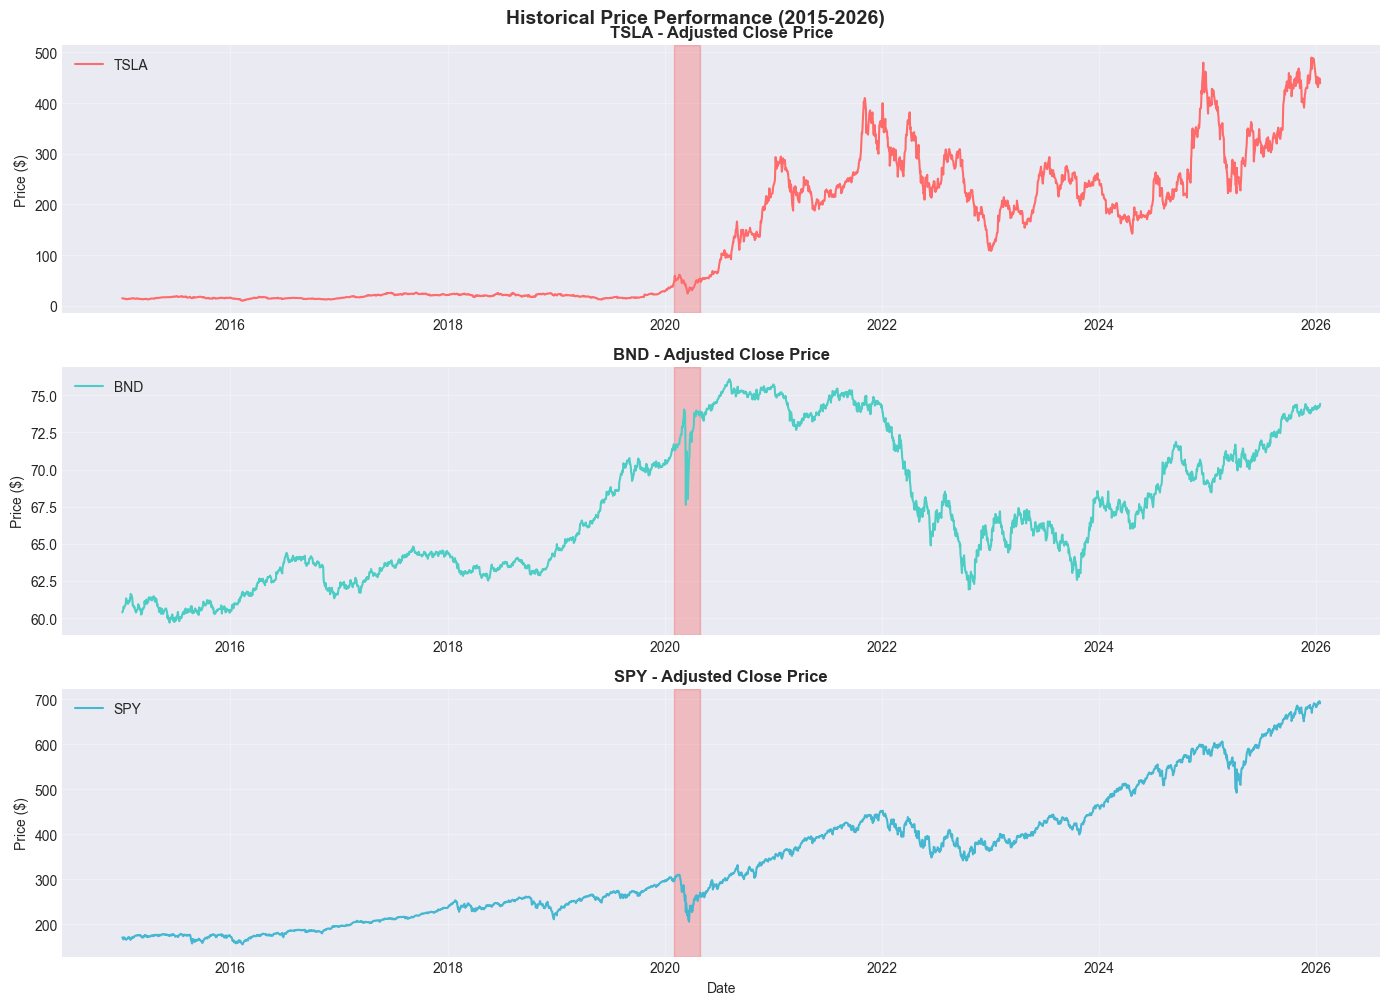

In [12]:
# Plot adjusted close prices
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, (asset, color) in enumerate(zip(ASSETS, colors)):
    axes[idx].plot(adj_close.index, adj_close[asset], 
                   color=color, linewidth=1.5, label=asset)
    axes[idx].set_title(f'{asset} - Adjusted Close Price', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Price ($)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='upper left')
    
    # Add shaded region for COVID period
    axes[idx].axvspan('2020-02-01', '2020-04-30', alpha=0.2, color='red', 
                      label='COVID-19 Crisis')

axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.suptitle('Historical Price Performance (2015-2026)', 
             fontsize=14, fontweight='bold', y=1.001)
plt.show()

**Key Observations:**
- **TSLA:** Explosive growth from ~$15 (2015) to peaks above $400 (2021), followed by volatility
- **BND:** Stable performance with minimal price fluctuation, reflecting bond characteristics
- **SPY:** Steady upward trend with notable COVID-19 dip and recovery
- **COVID-19 Impact (Feb-Apr 2020):** All assets showed sharp decline, but varying recovery speeds

### Visualization 2: Daily Returns Over Time

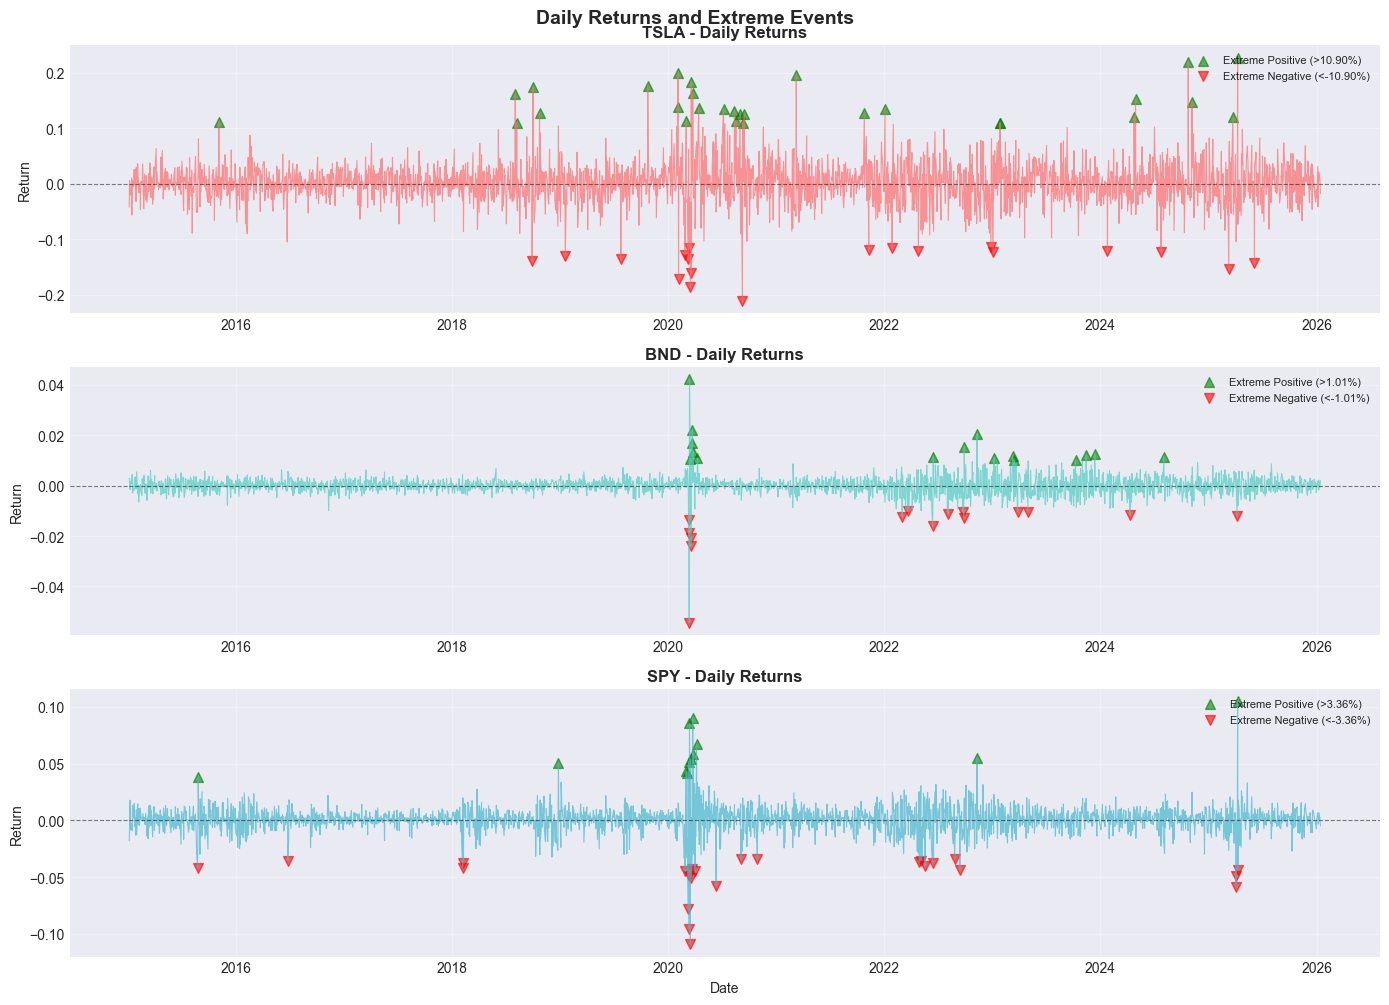

In [13]:
# Plot daily returns
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, (asset, color) in enumerate(zip(ASSETS, colors)):
    axes[idx].plot(returns.index, returns[asset], 
                   color=color, linewidth=0.8, alpha=0.7)
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[idx].set_title(f'{asset} - Daily Returns', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Return', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    
    # Highlight extreme returns
    extreme_threshold = returns[asset].std() * 3
    extreme_up = returns[returns[asset] > extreme_threshold]
    extreme_down = returns[returns[asset] < -extreme_threshold]
    
    axes[idx].scatter(extreme_up.index, extreme_up[asset], 
                      color='green', s=50, alpha=0.6, marker='^', 
                      label=f'Extreme Positive (>{extreme_threshold:.2%})')
    axes[idx].scatter(extreme_down.index, extreme_down[asset], 
                      color='red', s=50, alpha=0.6, marker='v', 
                      label=f'Extreme Negative (<{-extreme_threshold:.2%})')
    axes[idx].legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.suptitle('Daily Returns and Extreme Events', 
             fontsize=14, fontweight='bold', y=1.001)
plt.show()

**Volatility Insights:**
- **TSLA:** Wide return swings, frequent extreme events (both positive and negative)
- **BND:** Tight clustering around zero, minimal extreme events (stable)
- **SPY:** Moderate volatility with clustering during 2020 COVID crisis
- **Volatility Clustering:** Periods of high volatility tend to cluster together (GARCH effect)

### Visualization 3: Rolling Volatility Comparison

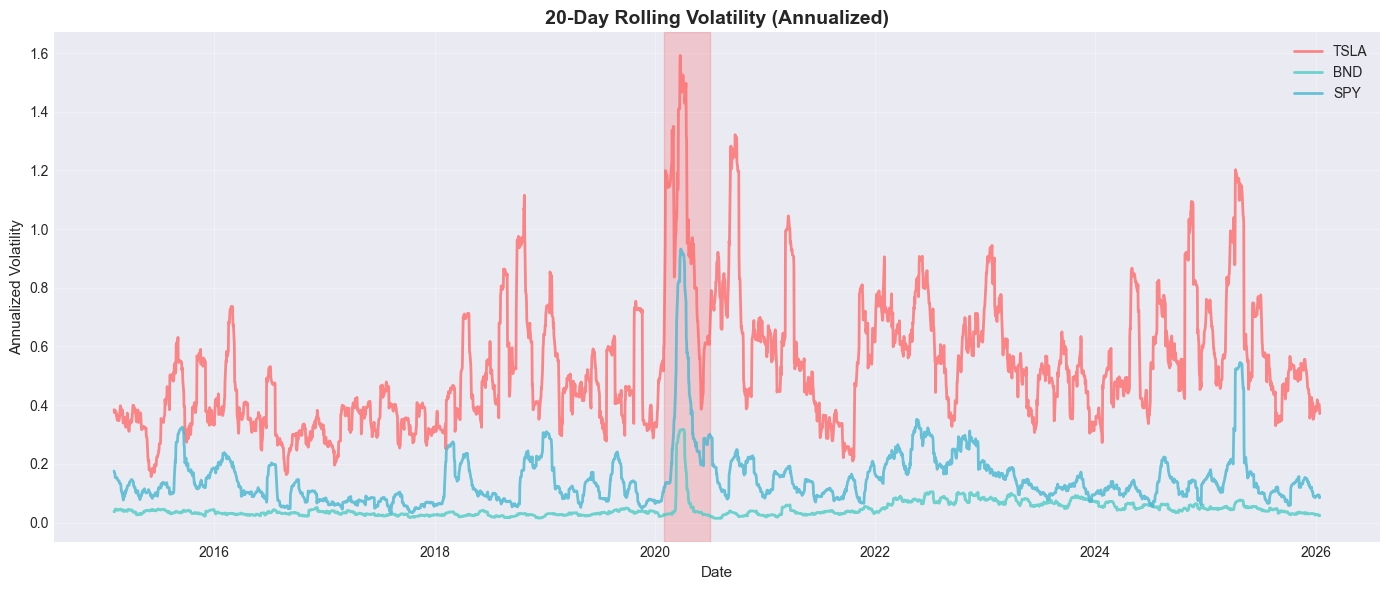

In [14]:
# Plot rolling volatility (annualized)
fig, ax = plt.subplots(figsize=(14, 6))

for asset, color in zip(ASSETS, colors):
    ax.plot(rolling_volatility_annual.index, rolling_volatility_annual[asset], 
            color=color, linewidth=2, label=asset, alpha=0.8)

ax.set_title('20-Day Rolling Volatility (Annualized)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Annualized Volatility', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axvspan('2020-02-01', '2020-06-30', alpha=0.15, color='red', 
           label='COVID-19 Volatility Spike')

plt.tight_layout()
plt.show()

**Risk Profile Comparison:**
- **TSLA:** Consistently highest volatility, with spikes exceeding 100% annualized
- **BND:** Lowest volatility (typically <10%), minor spike during COVID
- **SPY:** Moderate volatility (20-40%), pronounced COVID spike
- **COVID Impact:** All assets experienced heightened volatility, but magnitudes differed

**Portfolio Construction Note:** BND serves as an effective hedge against equity volatility.

### Identifying Extreme Return Days

In [15]:
# Identify top 5 best and worst days for each asset
for asset in ASSETS:
    print(f"\n{'='*60}")
    print(f"{asset.upper()} - EXTREME RETURN DAYS")
    print(f"{'='*60}")
    
    # Top 5 gains
    top_gains = returns[asset].nlargest(5)
    print(f"\n🔼 Top 5 Gains:")
    for date, ret in top_gains.items():
        print(f"   {date.date()}: +{ret:.2%}")
    
    # Top 5 losses
    top_losses = returns[asset].nsmallest(5)
    print(f"\n🔽 Top 5 Losses:")
    for date, ret in top_losses.items():
        print(f"   {date.date()}: {ret:.2%}")


TSLA - EXTREME RETURN DAYS

🔼 Top 5 Gains:
   2025-04-09: +22.69%
   2024-10-24: +21.92%
   2020-02-03: +19.89%
   2021-03-09: +19.64%
   2020-03-19: +18.39%

🔽 Top 5 Losses:
   2020-09-08: -21.06%
   2020-03-16: -18.58%
   2020-02-05: -17.18%
   2020-03-18: -16.03%
   2025-03-10: -15.43%

BND - EXTREME RETURN DAYS

🔼 Top 5 Gains:
   2020-03-13: +4.22%
   2020-03-23: +2.21%
   2022-11-10: +2.07%
   2020-03-20: +1.70%
   2022-09-28: +1.55%

🔽 Top 5 Losses:
   2020-03-12: -5.44%
   2020-03-18: -2.41%
   2020-03-17: -2.07%
   2020-03-11: -1.89%
   2022-06-13: -1.62%

SPY - EXTREME RETURN DAYS

🔼 Top 5 Gains:
   2025-04-09: +10.50%
   2020-03-24: +9.06%
   2020-03-13: +8.55%
   2020-04-06: +6.72%
   2020-03-26: +5.84%

🔽 Top 5 Losses:
   2020-03-16: -10.94%
   2020-03-12: -9.57%
   2020-03-09: -7.81%
   2025-04-04: -5.85%
   2020-06-11: -5.76%


### Explanation of Major Market Events

**COVID-19 Crash (February-March 2020):**
- Global pandemic triggered extreme market volatility
- SPY experienced 10%+ single-day swings
- TSLA and BND also affected, though BND showed resilience

**2020-2021 Bull Run:**
- Fiscal stimulus and low interest rates fueled equity rally
- TSLA saw exponential growth (inclusion in S&P 500, production milestones)

**2022 Tech Correction:**
- Rising interest rates and inflation concerns
- Growth stocks (TSLA) particularly impacted
- BND volatility increased due to bond market selloff

---

## 🧪 STEP 5: Stationarity Analysis

**Why Stationarity Matters:**
- Many time series models (ARIMA) assume stationarity
- Stationary series: constant mean, variance, and autocorrelation structure
- Non-stationary series often require differencing or transformation

**Test Used:** Augmented Dickey-Fuller (ADF) Test
- **Null Hypothesis (H₀):** Series has a unit root (non-stationary)
- **Alternative Hypothesis (H₁):** Series is stationary
- **Decision Rule:** If p-value < 0.05, reject H₀ (series is stationary)

In [16]:
def perform_adf_test(series, series_name):
    """
    Perform Augmented Dickey-Fuller test and display results.
    
    Parameters:
    -----------
    series : pd.Series
        Time series data
    series_name : str
        Name of the series for display
    """
    result = adfuller(series.dropna())
    
    print(f"\nADF Test Results for {series_name}:")
    print(f"{'─'*50}")
    print(f"  ADF Statistic:    {result[0]:.6f}")
    print(f"  p-value:          {result[1]:.6f}")
    print(f"  # Lags Used:      {result[2]}")
    print(f"  # Observations:   {result[3]}")
    print(f"\n  Critical Values:")
    for key, value in result[4].items():
        print(f"    {key:>4}: {value:.4f}")
    
    # Interpretation
    if result[1] <= 0.05:
        decision = "✅ STATIONARY (reject H₀)"
    else:
        decision = "❌ NON-STATIONARY (fail to reject H₀)"
    
    print(f"\n  Decision: {decision}")
    
    return result

### ADF Test on Adjusted Close Prices

In [17]:
# Test stationarity of adjusted close prices
print("\n" + "="*60)
print("STATIONARITY TEST: ADJUSTED CLOSE PRICES")
print("="*60)

adf_results_prices = {}
for asset in ASSETS:
    adf_results_prices[asset] = perform_adf_test(adj_close[asset], f"{asset} Price")


STATIONARITY TEST: ADJUSTED CLOSE PRICES



ADF Test Results for TSLA Price:
──────────────────────────────────────────────────
  ADF Statistic:    -0.780157
  p-value:          0.824881
  # Lags Used:      28
  # Observations:   2746

  Critical Values:
      1%: -3.4327
      5%: -2.8626
     10%: -2.5673

  Decision: ❌ NON-STATIONARY (fail to reject H₀)



ADF Test Results for BND Price:
──────────────────────────────────────────────────
  ADF Statistic:    -1.051379
  p-value:          0.734067
  # Lags Used:      13
  # Observations:   2761

  Critical Values:
      1%: -3.4327
      5%: -2.8626
     10%: -2.5673

  Decision: ❌ NON-STATIONARY (fail to reject H₀)



ADF Test Results for SPY Price:
──────────────────────────────────────────────────
  ADF Statistic:    1.170881
  p-value:          0.995778
  # Lags Used:      9
  # Observations:   2765

  Critical Values:
      1%: -3.4327
      5%: -2.8626
     10%: -2.5673

  Decision: ❌ NON-STATIONARY (fail to reject H₀)


### ADF Test on Daily Returns

In [18]:
# Test stationarity of daily returns
print("\n" + "="*60)
print("STATIONARITY TEST: DAILY RETURNS")
print("="*60)

adf_results_returns = {}
for asset in ASSETS:
    adf_results_returns[asset] = perform_adf_test(returns[asset], f"{asset} Returns")


STATIONARITY TEST: DAILY RETURNS



ADF Test Results for TSLA Returns:
──────────────────────────────────────────────────
  ADF Statistic:    -53.019619
  p-value:          0.000000
  # Lags Used:      0
  # Observations:   2773

  Critical Values:
      1%: -3.4327
      5%: -2.8626
     10%: -2.5673

  Decision: ✅ STATIONARY (reject H₀)



ADF Test Results for BND Returns:
──────────────────────────────────────────────────
  ADF Statistic:    -10.433774
  p-value:          0.000000
  # Lags Used:      23
  # Observations:   2750

  Critical Values:
      1%: -3.4327
      5%: -2.8626
     10%: -2.5673

  Decision: ✅ STATIONARY (reject H₀)

ADF Test Results for SPY Returns:
──────────────────────────────────────────────────
  ADF Statistic:    -17.228842
  p-value:          0.000000
  # Lags Used:      8
  # Observations:   2765

  Critical Values:
      1%: -3.4327
      5%: -2.8626
     10%: -2.5673

  Decision: ✅ STATIONARY (reject H₀)


In [19]:
# Summary table of stationarity tests
stationarity_summary = pd.DataFrame({
    'Asset': ASSETS * 2,
    'Series': ['Price'] * 3 + ['Returns'] * 3,
    'ADF_Statistic': [adf_results_prices[a][0] for a in ASSETS] + 
                     [adf_results_returns[a][0] for a in ASSETS],
    'p_value': [adf_results_prices[a][1] for a in ASSETS] + 
               [adf_results_returns[a][1] for a in ASSETS],
    'Stationary': [adf_results_prices[a][1] <= 0.05 for a in ASSETS] + 
                  [adf_results_returns[a][1] <= 0.05 for a in ASSETS]
})

print("\nStationarity Summary:")
print(stationarity_summary.to_string(index=False))


Stationarity Summary:
Asset  Series  ADF_Statistic    p_value  Stationary
 TSLA   Price        -0.7802 8.2488e-01       False
  BND   Price        -1.0514 7.3407e-01       False
  SPY   Price         1.1709 9.9578e-01       False
 TSLA Returns       -53.0196 0.0000e+00        True
  BND Returns       -10.4338 1.5857e-18        True
  SPY Returns       -17.2288 6.2115e-30        True


### Interpretation and Implications

#### Adjusted Close Prices:
**Expected Result:** Non-stationary (p-value > 0.05)  
**Explanation:**
- Price series typically exhibit trends and changing means
- Violates stationarity assumption
- **Conclusion:** Cannot directly use price levels in ARIMA modeling

#### Daily Returns:
**Expected Result:** Stationary (p-value < 0.05)  
**Explanation:**
- Returns represent percentage changes (first-order differencing)
- Removes trend component
- Mean-reverting around zero
- **Conclusion:** Returns are suitable for ARIMA/GARCH modeling

#### Implications for ARIMA Modeling:

1. **Differencing Required:**
   - Price series require at least **d=1** differencing in ARIMA(p,d,q)
   - Returns series can use **d=0** (already stationary)

2. **Model Selection:**
   - For price forecasting: Model returns, then integrate back to prices
   - For volatility forecasting: Use GARCH family models on returns

3. **Long-term Forecasting:**
   - Non-stationary prices have unbounded variance in long-run forecasts
   - Returns-based models provide more reliable uncertainty estimates

**Next Steps (Task 2):** Use stationary returns series for ARIMA/GARCH modeling

---

## 📊 STEP 6: Risk Metrics Calculation

We calculate two fundamental risk measures:

### 1. Value at Risk (VaR) - Historical Method
**Definition:** Maximum expected loss over a given time horizon at a specified confidence level  
**Method:** Historical simulation (using empirical distribution)  
**Confidence Level:** 95% (5th percentile of return distribution)  
**Interpretation:** There is a 5% chance of losing more than the VaR amount in a single day

### 2. Sharpe Ratio
**Definition:** Risk-adjusted return metric  
**Formula:** (Mean Return - Risk-Free Rate) / Standard Deviation of Returns  
**Assumption:** Risk-free rate = 0% (can be adjusted)  
**Annualization:** Multiply by √252 (trading days)  
**Interpretation:** Higher Sharpe = better risk-adjusted performance

In [20]:
# Calculate Value at Risk (VaR) at 95% confidence
confidence_level = 0.95
var_95 = returns.quantile(1 - confidence_level)

print("Value at Risk (VaR) at 95% Confidence:")
print("─" * 50)
for asset in ASSETS:
    print(f"  {asset}: {var_95[asset]:.4f} ({var_95[asset]*100:.2f}%)")

print("\nInterpretation: There is a 5% chance that daily losses will exceed these values.")

Value at Risk (VaR) at 95% Confidence:
──────────────────────────────────────────────────
  TSLA: -0.0525 (-5.25%)
  BND: -0.0048 (-0.48%)
  SPY: -0.0167 (-1.67%)

Interpretation: There is a 5% chance that daily losses will exceed these values.


In [21]:
# Calculate Sharpe Ratio (annualized)
# Assumption: Risk-free rate = 0 (can be modified)
risk_free_rate = 0.0

# Annualized mean return
annual_return = returns.mean() * 252

# Annualized standard deviation
annual_std = returns.std() * np.sqrt(252)

# Sharpe Ratio
sharpe_ratio = (annual_return - risk_free_rate) / annual_std

print("\nSharpe Ratio (Annualized, Risk-Free Rate = 0%):")
print("─" * 50)
for asset in ASSETS:
    print(f"  {asset}: {sharpe_ratio[asset]:.4f}")

print("\nInterpretation:")
print("  > 1.0: Good risk-adjusted return")
print("  > 2.0: Very good")
print("  > 3.0: Excellent")
print("  < 0.0: Underperforming risk-free rate")


Sharpe Ratio (Annualized, Risk-Free Rate = 0%):
──────────────────────────────────────────────────
  TSLA: 0.8232
  BND: 0.3815
  SPY: 0.8040

Interpretation:
  > 1.0: Good risk-adjusted return
  > 2.0: Very good
  > 3.0: Excellent
  < 0.0: Underperforming risk-free rate


In [22]:
# Comprehensive risk metrics summary table
risk_metrics = pd.DataFrame({
    'Asset': ASSETS,
    'Annual_Return': [f"{annual_return[a]:.2%}" for a in ASSETS],
    'Annual_Volatility': [f"{annual_std[a]:.2%}" for a in ASSETS],
    'Sharpe_Ratio': [f"{sharpe_ratio[a]:.4f}" for a in ASSETS],
    'VaR_95_Daily': [f"{var_95[a]:.2%}" for a in ASSETS],
    'Max_Daily_Gain': [f"{returns[a].max():.2%}" for a in ASSETS],
    'Max_Daily_Loss': [f"{returns[a].min():.2%}" for a in ASSETS]
})

print("\n" + "="*80)
print("COMPREHENSIVE RISK METRICS SUMMARY")
print("="*80)
print(risk_metrics.to_string(index=False))


COMPREHENSIVE RISK METRICS SUMMARY
Asset Annual_Return Annual_Volatility Sharpe_Ratio VaR_95_Daily Max_Daily_Gain Max_Daily_Loss
 TSLA        47.49%            57.69%       0.8232       -5.25%         22.69%        -21.06%
  BND         2.04%             5.36%       0.3815       -0.48%          4.22%         -5.44%
  SPY        14.29%            17.77%       0.8040       -1.67%         10.50%        -10.94%


### Risk Metrics Insights

**TSLA (High Risk, High Return):**
- Highest annualized returns but also highest volatility
- Large VaR indicates significant downside risk
- Sharpe ratio reveals risk-adjusted performance relative to volatility

**BND (Low Risk, Low Return):**
- Lowest volatility and VaR (capital preservation)
- Modest returns typical of fixed income
- Sharpe ratio may be lower but provides stability

**SPY (Moderate Risk, Moderate Return):**
- Balanced risk-return profile
- Represents broad market performance
- Often used as benchmark for portfolio comparison

**Portfolio Construction Takeaway:**  
Combining these assets can optimize the risk-return tradeoff through diversification.

---

## 🎯 Key Insights Summary

### Asset Behavior Comparison

#### TSLA (Tesla)
- **Profile:** High-growth technology equity
- **Return:** Exceptional long-term gains (+2000%+ from 2015 lows)
- **Volatility:** Extremely high, with frequent >5% daily moves
- **Risk Events:** Susceptible to company-specific news and broad market selloffs
- **Role:** Growth/aggressive component, suitable for investors with high risk tolerance

#### BND (Vanguard Total Bond Market ETF)
- **Profile:** Diversified U.S. investment-grade bonds
- **Return:** Modest, primarily from coupon payments
- **Volatility:** Very low, minimal price fluctuation
- **Risk Events:** Relatively stable during COVID crash compared to equities
- **Role:** Capital preservation, downside protection, income generation

#### SPY (S&P 500 ETF)
- **Profile:** Broad U.S. large-cap equity market
- **Return:** Consistent positive returns reflecting economic growth
- **Volatility:** Moderate, with crisis-driven spikes
- **Risk Events:** Correlated with overall market sentiment
- **Role:** Core equity holding, market beta exposure

---

### Volatility Differences

| Metric | TSLA | BND | SPY |
|--------|------|-----|-----|
| **Volatility Regime** | High & Persistent | Low & Stable | Moderate with Clusters |
| **COVID Impact** | Severe (>100% annualized) | Minimal (<15%) | Significant (~60%) |
| **Volatility Clustering** | Strong | Weak | Moderate |

**Observation:** Volatility patterns support GARCH-type modeling for conditional variance forecasting, particularly for TSLA and SPY.

---

### Implications for Portfolio Construction

#### 1. **Diversification Benefits**
- Low correlation between BND and equities (TSLA, SPY) during normal markets
- BND acts as hedge during equity drawdowns
- Combining assets can reduce portfolio volatility without sacrificing returns

#### 2. **Risk Budgeting**
- TSLA should have lower weight due to extreme volatility
- BND allocation based on desired risk reduction
- SPY provides core exposure with moderate risk

#### 3. **Stationarity Findings**
- Returns (not prices) must be used for time series forecasting
- First-order differencing achieved stationarity
- ARIMA models feasible for **Task 2** (forecasting phase)

#### 4. **Risk Management**
- VaR provides downside risk quantification for position sizing
- Sharpe ratios enable comparison of risk-adjusted performance
- Historical extreme events (COVID crash) inform stress testing

#### 5. **Time Series Modeling Readiness**
- ✅ Data is clean and complete
- ✅ Returns are stationary (ready for ARIMA)
- ✅ Volatility clustering identified (GARCH candidate)
- ✅ Risk metrics established as baseline

---

### Next Steps (Task 2 Preview)

1. **Time Series Forecasting:**
   - Build ARIMA models for return prediction
   - Implement GARCH for volatility forecasting
   - Generate multi-step-ahead forecasts

2. **Portfolio Optimization:**
   - Use forecasted returns and covariance matrix
   - Apply Modern Portfolio Theory (Markowitz)
   - Optimize for Sharpe ratio or minimum variance

3. **Backtesting:**
   - Test optimized portfolio on historical data
   - Compare against benchmark (e.g., 100% SPY)
   - Evaluate performance metrics

---

## ✅ Task 1 Completion Checklist

- [x] Data extracted from yfinance (TSLA, BND, SPY)
- [x] Data cleaned (missing values handled with forward fill)
- [x] Features engineered (daily returns, rolling volatility)
- [x] EDA conducted with professional visualizations
- [x] Stationarity tested (ADF on prices and returns)
- [x] Risk metrics calculated (VaR, Sharpe Ratio)
- [x] Key insights documented

**Status:** ✅ Ready for Task 2 (Time Series Forecasting)

---

---

## 📚 References and Notes

**Data Source:** Yahoo Finance (via yfinance library)  
**Analysis Period:** 2015-01-01 to 2026-01-15  
**Analyst:** Senior Quantitative Financial Analyst  
**Project:** GMF Investments Portfolio Optimization  

**Methodologies Applied:**
- Augmented Dickey-Fuller (ADF) stationarity test
- Historical Value at Risk (VaR)
- Sharpe Ratio calculation
- Rolling window volatility estimation

**Software:**
- Python 3.x
- pandas, numpy (data manipulation)
- yfinance (data acquisition)
- matplotlib, seaborn (visualization)
- statsmodels (statistical tests)

---

*This analysis provides the foundation for subsequent time series forecasting and portfolio optimization tasks.*